# Packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import mglearn

# SVR

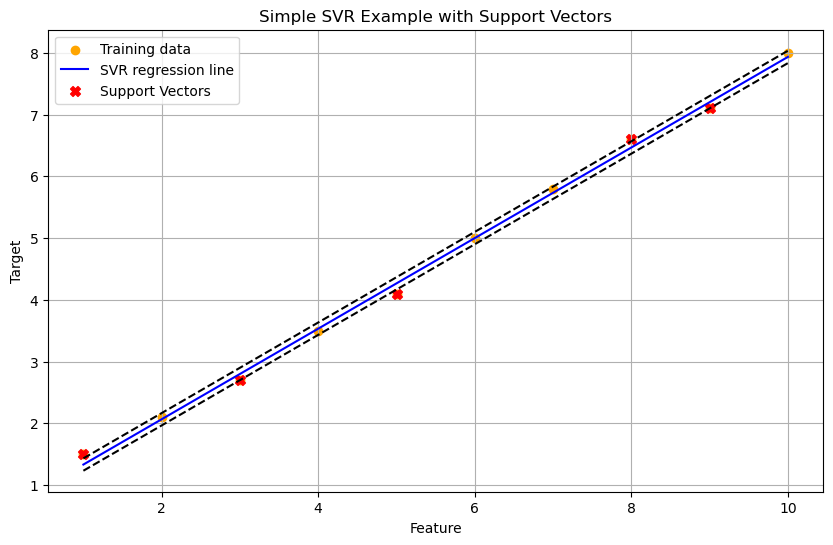

In [ ]:
from sklearn.svm import SVR

# 1. Create a simple dataset (1D)
# Let's make a simple dataset where the target y is a function of x
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])  # Features
y = np.array([1.5, 2.1, 2.7, 3.5, 4.1, 5.0, 5.8, 6.6, 7.1, 8.0])  # Targets

# 2. Create and fit the SVR model
epsilon = 0.1
svr = SVR(kernel='linear',C=100, epsilon=epsilon)
svr.fit(X, y)

# 3. Predict on the training data
y_pred = svr.predict(X)

# 4. Plot the data and the regression line
plt.figure(figsize=(10, 6))

# Plot the training data
plt.scatter(X, y, color='orange', label='Training data')

# Plot the SVR regression line
plt.plot(X, y_pred, color='blue', label='SVR regression line')
plt.plot(X, y_pred + epsilon, linestyle = '--', color = 'k')
plt.plot(X, y_pred - epsilon, linestyle = '--', color = 'k')

# Highlight the support vectors
plt.scatter(X[svr.support_], y[svr.support_], color='red', s=50, label='Support Vectors', marker='X')


# Adding titles and labels
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Simple SVR Example with Support Vectors')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 1. Load the California Housing dataset
california = fetch_california_housing()
X = california.data  # Features
y = california.target  # Target (house prices)

# Select one feature for simplicity (e.g., the first feature)
X_feature = X[:, 0].reshape(-1, 1)  # Take the first feature as a 2D array

# 2. Scale the data
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_feature)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# 3. Fit the SVR model
svr = SVR(kernel='linear', C=100, epsilon=0.1)
svr.fit(X_scaled, y_scaled)

# 4. Make predictions
y_pred_scaled = svr.predict(X_scaled)

# 5. Inverse transform the predicted values to get original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# 6. Plot the data and the regression line
plt.figure(figsize=(10, 6))

# Plot the training data
plt.scatter(X_feature, y, color='orange', label='Training data')

# Plot the SVR regression line
plt.plot(X_feature, y_pred, color='blue', label='SVR regression line')

# Add the epsilon margin
plt.plot(X_feature, y_pred + 0.1, linestyle='--', color='k')
plt.plot(X_feature, y_pred - 0.1, linestyle='--', color='k')

# Highlight the support vectors
plt.scatter(X_feature[svr.support_], y[svr.support_], color='red', s=50, label='Support Vectors', marker='X')

# Adding titles and labels
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('SVR Example with Support Vectors')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()